## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

In [29]:
# Compute demand slope
airfryers["demand_slope"] = -0.0384 * airfryers["brand_share"] * (1 - airfryers["brand_share"])

# Compute unit cost
airfryers["unit_cost"] = airfryers["avg_price"] + (airfryers["brand_share"] / airfryers["demand_slope"])

# Compute markup
airfryers["markup"] = airfryers["avg_price"] - airfryers["unit_cost"]

# Compute average profit
airfryers["avg_profit"] = airfryers["brand_share"] * airfryers["markup"]

Questions:

1. What are the average unit costs and markups for each brand over the years?

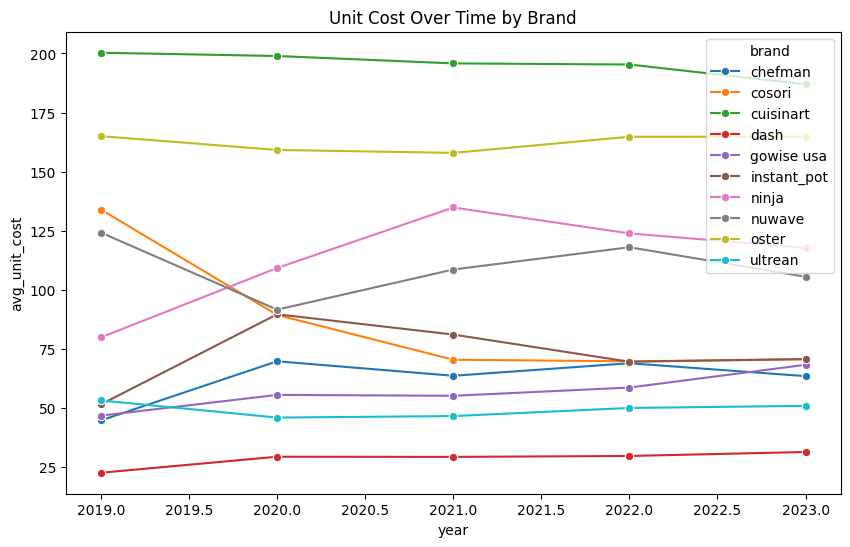

In [11]:
brand_year_trends = airfryers.groupby(["brand", "year"]).agg(
    avg_unit_cost=("unit_cost", "mean"),
    avg_markup=("markup", "mean")
).reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.lineplot(data=brand_year_trends, x="year", y="avg_unit_cost", hue="brand", marker="o")
plt.title("Unit Cost Over Time by Brand")
plt.show()

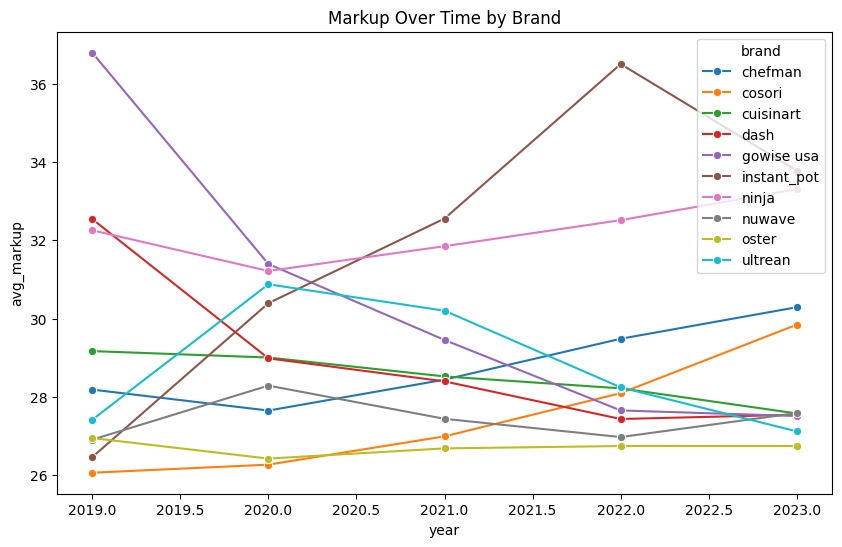

In [12]:
plt.figure(figsize=(10,6))
sns.lineplot(data=brand_year_trends, x="year", y="avg_markup", hue="brand", marker="o")
plt.title("Markup Over Time by Brand")
plt.show()

2. Are any inferred unit costs negative? If so, what might that mean?


In [13]:
airfryers[airfryers["unit_cost"] < 0][["brand", "year", "brand_share", "avg_price"]]

,brand,year,brand_share,avg_price


There are no inferred unit costs that are negative. This is economically consistent, since negative production costs are not realistic. It suggests that the demand estimates and demand slopes are stable and that shares are in a reasonable range.

3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost. Do more expensive products have higher consumer satisfaction?


In [14]:
brand_summary = airfryers.groupby("brand").agg(
    avg_unit_cost=("unit_cost", "mean"),
    avg_rating=("avg_rating", "mean"),
    avg_price=("avg_price", "mean")
).reset_index()

brand_summary.sort_values("avg_unit_cost", ascending=False)

,brand,avg_unit_cost,avg_rating,avg_price
2,cuisinart,195.450165,4.438892,223.947093
8,oster,162.324216,4.388653,189.031284
6,ninja,113.115048,4.742064,145.342541
7,nuwave,109.586995,4.389798,137.024384
1,cosori,86.817031,4.656292,114.267950
5,instant_pot,72.524055,4.559323,104.461353
0,chefman,62.129576,4.427966,90.938411
4,gowise usa,56.895189,4.576990,87.454781
9,ultrean,49.345111,4.672616,78.114606
3,dash,28.499996,4.476394,57.478927


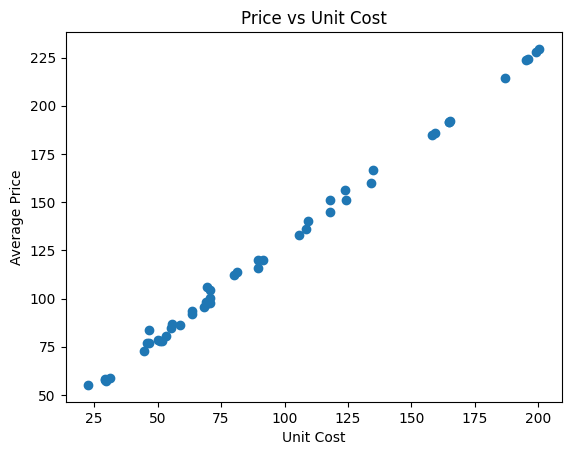

In [15]:
import matplotlib.pyplot as plt

plt.scatter(airfryers["unit_cost"], airfryers["avg_price"])
plt.xlabel("Unit Cost")
plt.ylabel("Average Price")
plt.title("Price vs Unit Cost")
plt.show()

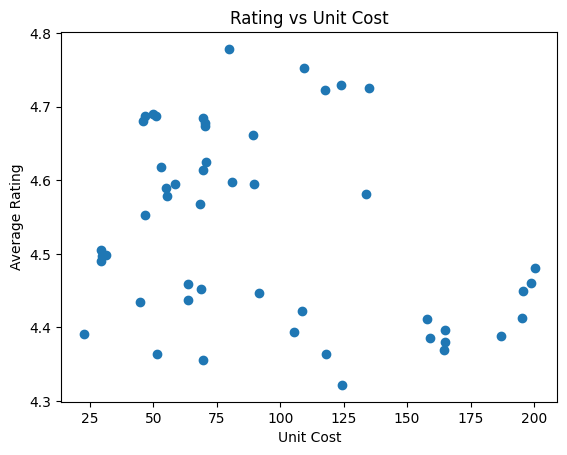

In [16]:
plt.scatter(airfryers["unit_cost"], airfryers["avg_rating"])
plt.xlabel("Unit Cost")
plt.ylabel("Average Rating")
plt.title("Rating vs Unit Cost")
plt.show()

Cuisinart, Oster, and Ninja have the highest average unit cost. Comparing average rating and unit cost, there is no clear relationship between the two variables. This suggests that brand rating cannot be used to reliably infer the brand's average unit cost. Additionally, we cannot conclude that more expensive products have higher consumer satisfication.

4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.


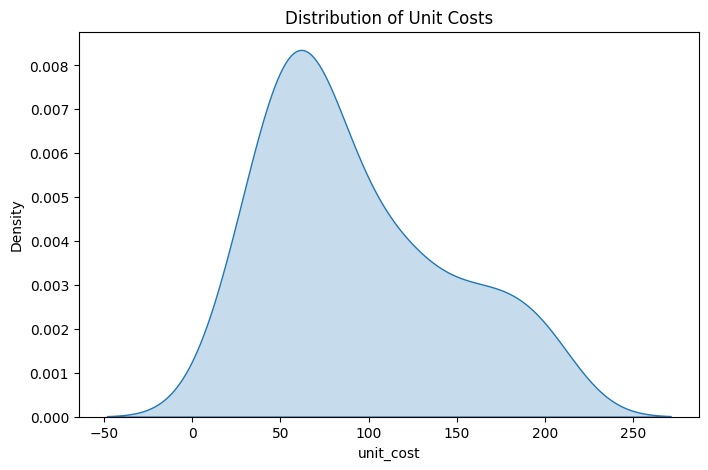

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.kdeplot(data=airfryers, x="unit_cost", fill=True)
plt.title("Distribution of Unit Costs")
plt.show()

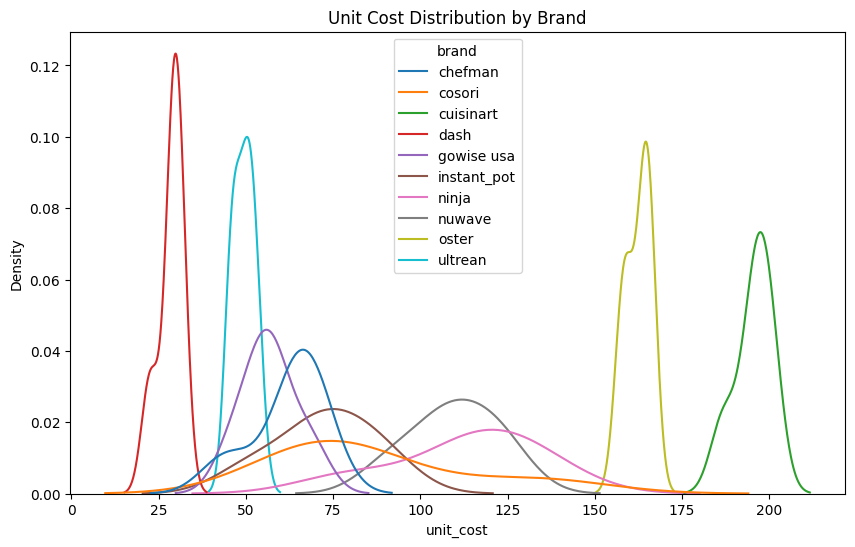

In [18]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=airfryers, x="unit_cost", hue="brand", common_norm=False)
plt.title("Unit Cost Distribution by Brand")
plt.show()

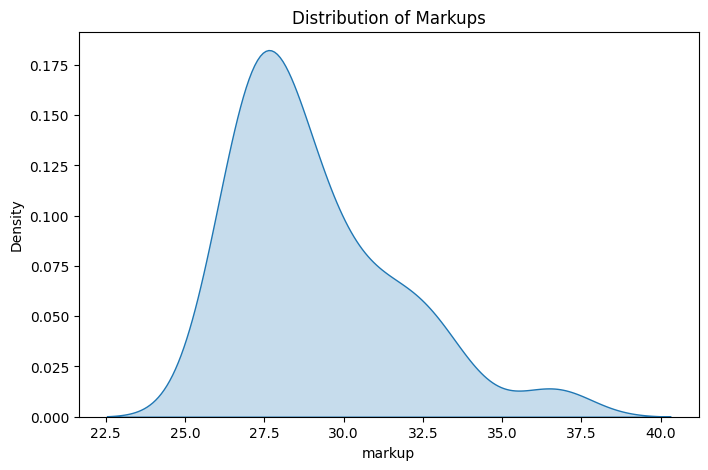

In [19]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=airfryers, x="markup", fill=True)
plt.title("Distribution of Markups")
plt.show()

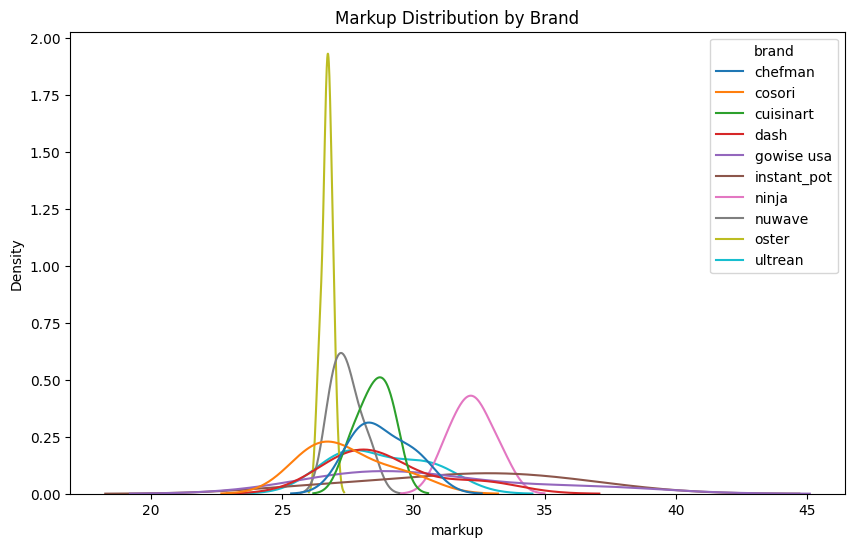

In [20]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=airfryers, x="markup", hue="brand", common_norm=False)
plt.title("Markup Distribution by Brand")
plt.show()

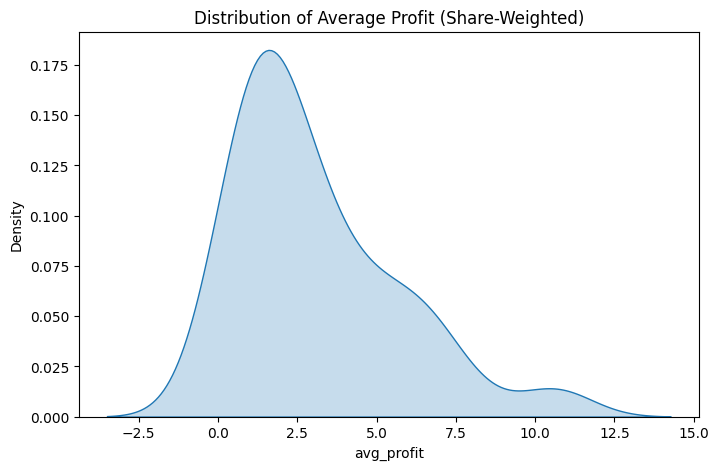

In [21]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=airfryers, x="avg_profit", fill=True)
plt.title("Distribution of Average Profit (Share-Weighted)")
plt.show()

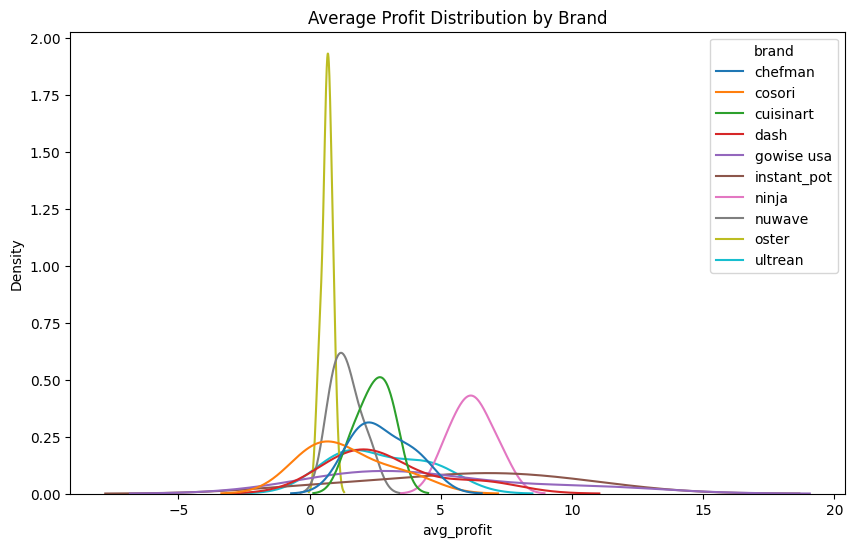

In [22]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=airfryers, x="avg_profit", hue="brand", common_norm=False)
plt.title("Average Profit Distribution by Brand")
plt.show()

5. Which brands have the highest share-weighted average profit?



In [23]:
brand_profit = airfryers.groupby("brand").agg(
    avg_share_weighted_profit=("avg_profit", "mean")
).reset_index()

brand_profit.sort_values("avg_share_weighted_profit", ascending=False)

,brand,avg_share_weighted_profit
6,ninja,6.185826
5,instant_pot,5.895631
4,gowise usa,4.517925
3,dash,2.937265
0,chefman,2.767168
9,ultrean,2.727828
2,cuisinart,2.455261
1,cosori,1.409252
7,nuwave,1.395722
8,oster,0.665401


Ninja, Insta Pot, and Gowsie USA have the highest share weight average profit. These brands generally have a stronger brand effect and consistently high market shares. They generate high profits through higher markups and large market shares, indicating strong prcing power and consumer preference in the market.

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.